# 16 - Leave-One-Gravity-Out CV and Uncertainty Analysis

## Objective

This notebook validates the final forward strategy under a gravity-based OOD split.

Random KFold CV mainly validates interpolation. Leave-One-Gravity-Out CV validates what happens when one full gravity regime is absent from training.

Compared strategies:

- baseline ExtraTrees
- hybrid MLP-distance model
- alpha25 controlled blend
- physics residual model

Main outputs:

- LOGO metrics by strategy and target
- LOGO metrics by held-out gravity
- bootstrap confidence intervals
- paired bootstrap differences
- final recommendation between baseline and alpha25

## 1. Imports and paths

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FORWARD_DIR = PROJECT_ROOT / "data" / "raw" / "forward_prediction"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
SUBMISSIONS_DIR = OUTPUTS_DIR / "submissions"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = OUTPUTS_DIR / "figures"
for path in [REPORTS_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Forward data:", FORWARD_DIR)
print("Reports:", REPORTS_DIR)

Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Forward data: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/forward_prediction
Reports: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/reports


## 2. Load data

In [2]:
input_cols = ["energy", "angle_rad", "coupling", "strength", "porosity", "gravity", "atmosphere", "shape_factor"]
target_cols = ["P80", "fines_frac", "oversize_frac", "R95", "R50_fines", "R50_oversize"]
fragmentation_targets = ["P80", "fines_frac", "oversize_frac"]
distance_targets = ["R95", "R50_fines", "R50_oversize"]

raw_train = pd.read_csv(FORWARD_DIR / "train.csv")[input_cols]
raw_test = pd.read_csv(FORWARD_DIR / "test.csv")[input_cols]
y = pd.read_csv(FORWARD_DIR / "train_labels.csv")[target_cols]

print("Train:", raw_train.shape)
print("Test:", raw_test.shape)
print("Targets:", y.shape)
print("Train gravity:", sorted(raw_train["gravity"].unique()))
print("Test gravity:", sorted(raw_test["gravity"].unique()))

Train: (2930, 8)
Test: (492, 8)
Targets: (2930, 6)
Train gravity: [np.float64(1.62), np.float64(3.71), np.float64(9.81)]
Test gravity: [np.float64(1.02), np.float64(1.38), np.float64(4.91), np.float64(7.03), np.float64(10.47)]


## 3. Feature engineering and model helpers

In [3]:
class PhysicsFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, use_advanced: bool = False):
        self.use_advanced = use_advanced

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()[input_cols]
        eps = 1e-9

        X["effective_energy"] = X["energy"] * X["coupling"]
        X["log_energy"] = np.log1p(X["energy"])
        X["log_effective_energy"] = np.log1p(X["effective_energy"])

        X["sin_angle"] = np.sin(X["angle_rad"])
        X["cos_angle"] = np.cos(X["angle_rad"])
        X["tan_angle"] = np.tan(X["angle_rad"])

        X["horizontal_energy"] = X["effective_energy"] * X["cos_angle"]
        X["vertical_energy"] = X["effective_energy"] * X["sin_angle"]
        X["vertical_horizontal_ratio"] = X["vertical_energy"] / (X["horizontal_energy"] + eps)

        X["energy_per_strength"] = X["energy"] / (X["strength"] + eps)
        X["effective_energy_per_strength"] = X["effective_energy"] / (X["strength"] + eps)
        X["material_resistance_index"] = X["strength"] * (1 - X["porosity"])
        X["fragmentation_index"] = X["effective_energy"] * X["porosity"] / (X["strength"] + eps)
        X["coupling_porosity"] = X["coupling"] * X["porosity"]
        X["coupling_atmosphere"] = X["coupling"] * X["atmosphere"]
        X["porosity_strength"] = X["porosity"] * X["strength"]

        X["energy_per_gravity"] = X["energy"] / (X["gravity"] + eps)
        X["effective_energy_per_gravity"] = X["effective_energy"] / (X["gravity"] + eps)
        X["horizontal_energy_per_gravity"] = X["horizontal_energy"] / (X["gravity"] + eps)
        X["vertical_energy_per_gravity"] = X["vertical_energy"] / (X["gravity"] + eps)

        X["drag_proxy"] = X["atmosphere"] * X["shape_factor"]
        X["drag_per_gravity"] = X["drag_proxy"] / (X["gravity"] + eps)
        X["atmosphere_shape_energy"] = X["atmosphere"] * X["shape_factor"] * X["effective_energy"]
        X["atmosphere_per_gravity"] = X["atmosphere"] / (X["gravity"] + eps)

        X["pi_gravity_proxy"] = (X["gravity"] * X["coupling"]) / (X["energy"] + eps)
        X["pi_strength_proxy"] = X["strength"] / (X["gravity"] * X["coupling"] + eps)
        X["pi_atmosphere_proxy"] = X["atmosphere"] / (X["gravity"] * X["coupling"] + eps)

        X["porosity_regime"] = (X["porosity"] > 0.15).astype(int)
        X["strength_regime"] = (X["strength"] > 2.6).astype(int)
        X["angle_regime"] = (X["angle_rad"] > 0.95).astype(int)
        X["atm_regime"] = (X["atmosphere"] > 0.30).astype(int)
        X["regime_combo"] = X["porosity_regime"]*8 + X["strength_regime"]*4 + X["angle_regime"]*2 + X["atm_regime"]

        X["scaled_energy"] = X["effective_energy"] / (X["strength"] * np.sqrt(X["gravity"]) + eps)
        X["fragility"] = X["porosity"] / (X["strength"] + eps)
        X["range_proxy"] = (X["effective_energy"] * X["cos_angle"]**2) / (X["gravity"] * X["strength"] + eps)
        X["energy_sin_angle"] = X["energy"] * X["sin_angle"]
        X["momentum_proxy"] = X["effective_energy"] * X["sin_angle"]

        X["coupling_per_atm_clipped"] = X["coupling"] / (X["atmosphere"] + 1e-3)
        X["log_coupling_per_atm"] = np.log1p(X["coupling_per_atm_clipped"])
        X["retention_factor"] = X["atmosphere"] * X["drag_proxy"] / (X["energy"] + eps)

        if self.use_advanced:
            X["stress_ratio_compact"] = X["effective_energy"] / (X["material_resistance_index"] + eps)
            X["sqrt_effective_energy_per_strength"] = np.sqrt(X["effective_energy_per_strength"].clip(lower=0))
            X["sqrt_effective_energy_per_gravity"] = np.sqrt(X["effective_energy_per_gravity"].clip(lower=0))

        return X


class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = list(columns)

    def fit(self, X, y=None):
        missing = [c for c in self.columns if c not in X.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")
        return self

    def transform(self, X):
        return X[self.columns].copy()


def build_extratrees(random_state=42, n_estimators=800):
    return ExtraTreesRegressor(
        n_estimators=n_estimators,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=random_state,
        n_jobs=-1,
    )


def build_mlp(random_state=42):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(128,64),
            activation="relu",
            solver="adam",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=1200,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=40,
            random_state=random_state,
        )),
    ])


def clip_predictions(preds, target):
    preds = np.asarray(preds).copy()
    return np.clip(preds, 0, 1) if target in ["fines_frac", "oversize_frac"] else np.clip(preds, 0, None)


def regression_metrics(y_true, y_pred, target_name=None):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    abs_err = np.abs(y_pred - y_true)

    out = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Median_AE": np.median(abs_err),
        "P90_AE": np.percentile(abs_err,90),
        "P95_AE": np.percentile(abs_err,95),
        "Bias": float(np.mean(y_pred-y_true)),
    }

    if target_name is not None:
        out["normalized_MAE"] = out["MAE"] / (y[target_name].std() + 1e-9)

    return out

## 4. Feature sets

In [4]:
raw_features = input_cols.copy()

fragmentation_features_v1 = raw_features + [
    "effective_energy","log_effective_energy","sin_angle","cos_angle","horizontal_energy","vertical_energy",
    "energy_per_strength","effective_energy_per_strength","material_resistance_index","fragmentation_index",
    "coupling_porosity","coupling_atmosphere","porosity_strength","drag_proxy","atmosphere_shape_energy",
    "pi_strength_proxy","pi_atmosphere_proxy","scaled_energy","fragility","energy_sin_angle","momentum_proxy",
    "porosity_regime","strength_regime","angle_regime","atm_regime","regime_combo"
]

fragmentation_features_v2 = fragmentation_features_v1 + [
    "stress_ratio_compact","sqrt_effective_energy_per_strength"
]

distance_features_v1 = raw_features + [
    "effective_energy","log_effective_energy","sin_angle","cos_angle","horizontal_energy","vertical_energy",
    "energy_per_gravity","effective_energy_per_gravity","horizontal_energy_per_gravity","vertical_energy_per_gravity",
    "drag_proxy","drag_per_gravity","atmosphere_shape_energy","atmosphere_per_gravity",
    "pi_gravity_proxy","pi_atmosphere_proxy","scaled_energy","range_proxy","energy_sin_angle","momentum_proxy",
    "porosity_regime","strength_regime","angle_regime","atm_regime","regime_combo"
]

final_target_config = {
    "P80": {"feature_version":"v2", "features":fragmentation_features_v2},
    "fines_frac": {"feature_version":"v2", "features":fragmentation_features_v2},
    "oversize_frac": {"feature_version":"v2", "features":fragmentation_features_v2},
    "R95": {"feature_version":"v1", "features":distance_features_v1},
    "R50_fines": {"feature_version":"v1", "features":distance_features_v1},
    "R50_oversize": {"feature_version":"v1", "features":distance_features_v1},
}


def build_target_et_pipeline(target, random_state=42, n_estimators=800):
    cfg = final_target_config[target]

    return Pipeline([
        ("features", PhysicsFeatureEngineer(use_advanced=cfg["feature_version"]=="v2")),
        ("select", ColumnSelector(cfg["features"])),
        ("model", build_extratrees(random_state=random_state, n_estimators=n_estimators)),
    ])


def build_feature_matrix_for_target(X_raw, target):
    cfg = final_target_config[target]
    X_fe = PhysicsFeatureEngineer(use_advanced=cfg["feature_version"]=="v2").fit_transform(X_raw)
    return X_fe[cfg["features"]].copy()


display(pd.DataFrame([
    {"target_family":"fragmentation", "n_features":len(fragmentation_features_v2)},
    {"target_family":"distance", "n_features":len(distance_features_v1)}
]))

,target_family,n_features
0,fragmentation,36
1,distance,33


## 5. Optional physics residual functions

In [5]:
EPS = 1e-9

def physics_baseline(X, params):
    X = pd.DataFrame(X).copy()
    E_eff = X["energy"].values * X["coupling"].values
    horizontal_E = E_eff * np.cos(X["angle_rad"].values)**2

    core = ((horizontal_E + EPS) / (X["gravity"].values + EPS)) ** params["alpha"]
    porosity_corr = 1.0 + params["beta"] * X["porosity"].values
    atm_corr = np.exp(-params["gamma"] * X["atmosphere"].values * X["shape_factor"].values)
    strength_corr = (X["strength"].values + EPS) ** params["delta"]

    return np.clip(params["k"] * core * porosity_corr * atm_corr * strength_corr, EPS, None)


def fit_physics_baseline_simple(X, y_target):
    from scipy.optimize import minimize

    keys = ["k","alpha","beta","gamma","delta"]
    x0 = np.array([100.0, 0.5, 1.0, 1.0, -0.3])
    y_log = np.log(np.clip(y_target, EPS, None))

    def loss(x):
        p = dict(zip(keys,x))
        pred = physics_baseline(X,p)
        return np.mean((np.log(np.clip(pred, EPS, None)) - y_log)**2)

    bounds = [(1,10000),(0.1,1.5),(-2,5),(-1,5),(-2,2)]
    res = minimize(loss, x0, method="L-BFGS-B", bounds=bounds)

    return dict(zip(keys, res.x))

## 6. Leave-One-Gravity-Out validation

In [6]:
def leave_one_gravity_out_predictions(include_hybrid=True, include_physics_residual=True, alpha=0.25, random_state=42, n_estimators=800):
    gravity_values = sorted(raw_train["gravity"].unique())

    oof_base = pd.DataFrame(index=y.index, columns=target_cols, dtype=float)
    oof_hybrid = pd.DataFrame(index=y.index, columns=target_cols, dtype=float)
    oof_alpha = pd.DataFrame(index=y.index, columns=target_cols, dtype=float)
    oof_physres = pd.DataFrame(index=y.index, columns=target_cols, dtype=float)

    fold_rows = []

    for fold, g_valid in enumerate(gravity_values, start=1):
        valid_idx = raw_train.index[raw_train["gravity"] == g_valid].tolist()
        train_idx = raw_train.index[raw_train["gravity"] != g_valid].tolist()

        X_train = raw_train.loc[train_idx].reset_index(drop=True)
        X_valid = raw_train.loc[valid_idx].reset_index(drop=True)
        y_train = y.loc[train_idx].reset_index(drop=True)

        print(f"LOGO fold {fold}: validate gravity={g_valid}, train={len(train_idx)}, valid={len(valid_idx)}")

        for i, target in enumerate(target_cols):
            et_pipe = build_target_et_pipeline(
                target,
                random_state=random_state + fold*10 + i,
                n_estimators=n_estimators,
            )

            et_pipe.fit(X_train, y_train[target])
            base_pred = clip_predictions(et_pipe.predict(X_valid), target)
            oof_base.loc[valid_idx, target] = base_pred

            if include_hybrid and target in distance_targets:
                X_train_target = build_feature_matrix_for_target(X_train, target)
                X_valid_target = build_feature_matrix_for_target(X_valid, target)

                mlp = build_mlp(random_state=random_state + 100 + fold*10 + i)
                mlp.fit(X_train_target, y_train[target])

                mlp_pred = clip_predictions(mlp.predict(X_valid_target), target)
                hybrid_pred = clip_predictions((1 - 0.65) * base_pred + 0.65 * mlp_pred, target)
                alpha_pred = clip_predictions((1 - alpha) * base_pred + alpha * hybrid_pred, target)
            else:
                hybrid_pred = base_pred
                alpha_pred = base_pred

            oof_hybrid.loc[valid_idx, target] = hybrid_pred
            oof_alpha.loc[valid_idx, target] = alpha_pred

            if include_physics_residual and target in distance_targets:
                X_train_fe = PhysicsFeatureEngineer(use_advanced=False).fit_transform(X_train)
                X_valid_fe = PhysicsFeatureEngineer(use_advanced=False).fit_transform(X_valid)

                X_train_dist = X_train_fe[[c for c in distance_features_v1 if c in X_train_fe.columns]]
                X_valid_dist = X_valid_fe[[c for c in distance_features_v1 if c in X_valid_fe.columns]]

                params = fit_physics_baseline_simple(X_train, y_train[target].values)
                phys_train = physics_baseline(X_train, params)
                phys_valid = physics_baseline(X_valid, params)

                residual_model = build_extratrees(
                    random_state=random_state + 200 + fold*10 + i,
                    n_estimators=n_estimators,
                )

                residual_model.fit(X_train_dist.values, y_train[target].values - phys_train)
                physres_pred = clip_predictions(phys_valid + residual_model.predict(X_valid_dist.values), target)
            else:
                physres_pred = base_pred

            oof_physres.loc[valid_idx, target] = physres_pred

        fold_rows.append({
            "fold":fold,
            "valid_gravity":g_valid,
            "n_train":len(train_idx),
            "n_valid":len(valid_idx),
        })

    return {
        "base": oof_base,
        "hybrid_w_0.65": oof_hybrid,
        "alpha25": oof_alpha,
        "physics_residual": oof_physres,
        "folds": pd.DataFrame(fold_rows),
    }


RUN_LOGO = True

if RUN_LOGO:
    logo_outputs = leave_one_gravity_out_predictions(
        include_hybrid=True,
        include_physics_residual=True,
        alpha=0.25,
        random_state=42,
        n_estimators=800,
    )
    display(logo_outputs["folds"])
else:
    print("LOGO validation skipped.")

LOGO fold 1: validate gravity=1.62, train=1940, valid=990
LOGO fold 2: validate gravity=3.71, train=1930, valid=1000
LOGO fold 3: validate gravity=9.81, train=1990, valid=940


,fold,valid_gravity,n_train,n_valid
0,1,1.62,1940,990
1,2,3.71,1930,1000
2,3,9.81,1990,940


## 7. LOGO metrics by strategy and target

In [7]:
def evaluate_oof_predictions(oof_dict):
    rows = []

    for strategy, oof_df in oof_dict.items():
        if strategy == "folds":
            continue

        for target in target_cols:
            m = regression_metrics(y[target], oof_df[target], target_name=target)
            m["strategy"] = strategy
            m["target"] = target
            rows.append(m)

    return pd.DataFrame(rows)


logo_metrics = evaluate_oof_predictions(logo_outputs)

display(
    logo_metrics
    .sort_values(["target","normalized_MAE"])
    [["target","strategy","MAE","RMSE","R2","P95_AE","Bias","normalized_MAE"]]
)

logo_summary = (
    logo_metrics
    .groupby("strategy")
    .agg(
        mean_norm_MAE=("normalized_MAE","mean"),
        mean_R2=("R2","mean"),
        mean_P95_AE=("P95_AE","mean"),
        mean_abs_bias=("Bias", lambda s: np.mean(np.abs(s))),
    )
    .reset_index()
    .sort_values("mean_norm_MAE")
)

display(logo_summary)

logo_metrics.to_csv(REPORTS_DIR / "16_logo_metrics_by_strategy_target.csv", index=False)
logo_summary.to_csv(REPORTS_DIR / "16_logo_summary_by_strategy.csv", index=False)

,target,strategy,MAE,RMSE,R2,P95_AE,Bias,normalized_MAE
0,P80,base,7.841240,10.349198,0.975220,21.382564,0.437683,0.119249
6,P80,hybrid_w_0.65,7.841240,10.349198,0.975220,21.382564,0.437683,0.119249
12,P80,alpha25,7.841240,10.349198,0.975220,21.382564,0.437683,0.119249
18,P80,physics_residual,7.841240,10.349198,0.975220,21.382564,0.437683,0.119249
10,R50_fines,hybrid_w_0.65,85.758140,122.130095,0.755231,277.177188,-18.566182,0.347341
22,R50_fines,physics_residual,121.285667,173.513075,0.505945,393.643866,-51.888721,0.491237
16,R50_fines,alpha25,188.334070,223.560726,0.179834,444.724439,-22.595067,0.762799
4,R50_fines,base,224.926193,261.725704,-0.124096,508.029820,-23.938028,0.911006
11,R50_oversize,hybrid_w_0.65,41.672160,58.567386,0.708187,123.138779,-3.474324,0.384298
23,R50_oversize,physics_residual,47.787989,73.614215,0.538983,167.797385,-22.860046,0.440698


,strategy,mean_norm_MAE,mean_R2,mean_P95_AE,mean_abs_bias
2,hybrid_w_0.65,0.221285,0.859072,111.932172,6.712336
3,physics_residual,0.261173,0.775831,148.296118,19.438114
0,alpha25,0.392738,0.615040,176.524145,8.890867
1,base,0.453561,0.492291,201.447550,9.617044


## 8. LOGO metrics by held-out gravity

,target,heldout_gravity,strategy,MAE,P95_AE,Bias,normalized_MAE
10,R50_fines,1.62,hybrid_w_0.65,156.307997,361.604480,-143.265072,0.633085
28,R50_fines,1.62,physics_residual,250.134193,484.713921,-249.207310,1.013104
19,R50_fines,1.62,alpha25,311.897077,554.660642,-311.897077,1.263259
1,R50_fines,1.62,base,368.107745,622.834575,-368.107745,1.490926
13,R50_fines,3.71,hybrid_w_0.65,69.883245,136.035903,62.175471,0.283044
31,R50_fines,3.71,physics_residual,70.241419,144.676265,59.017941,0.284495
22,R50_fines,3.71,alpha25,130.017442,215.786407,129.551283,0.526602
4,R50_fines,3.71,base,152.328720,252.080510,152.009887,0.616968
16,R50_fines,9.81,hybrid_w_0.65,28.343817,57.252930,26.870251,0.114799
34,R50_fines,9.81,physics_residual,39.885887,73.992674,37.939728,0.161548


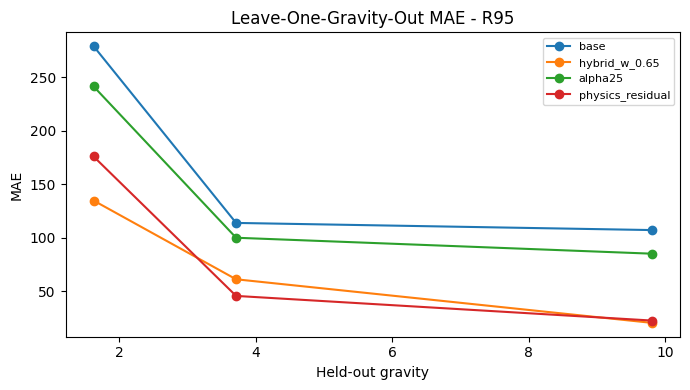

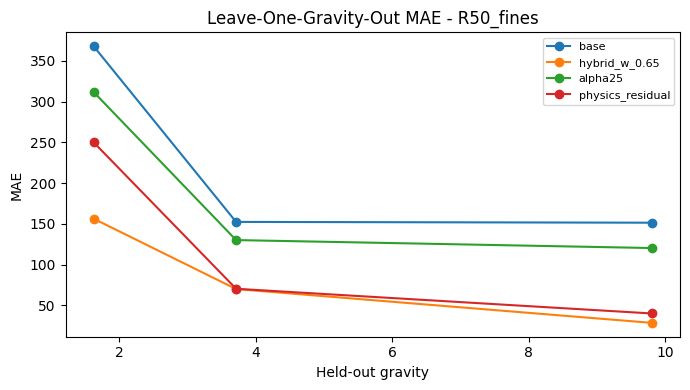

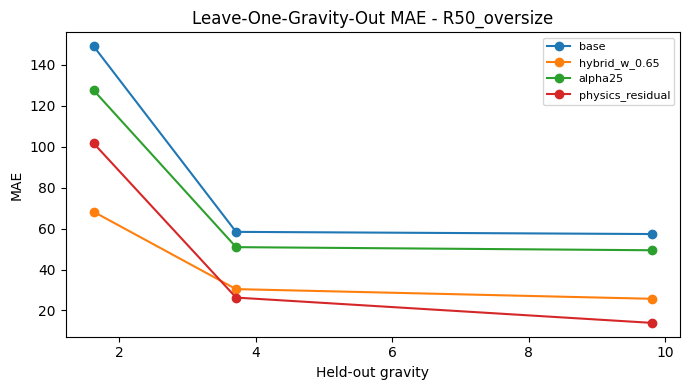

In [8]:
gravity_metric_rows = []

for strategy, oof_df in logo_outputs.items():
    if strategy == "folds":
        continue

    for g_valid in sorted(raw_train["gravity"].unique()):
        mask = raw_train["gravity"] == g_valid

        for target in distance_targets:
            m = regression_metrics(
                y.loc[mask, target],
                oof_df.loc[mask, target],
                target_name=target,
            )

            m["strategy"] = strategy
            m["heldout_gravity"] = g_valid
            m["target"] = target
            gravity_metric_rows.append(m)

gravity_metrics = pd.DataFrame(gravity_metric_rows)

display(
    gravity_metrics
    .sort_values(["target","heldout_gravity","MAE"])
    [["target","heldout_gravity","strategy","MAE","P95_AE","Bias","normalized_MAE"]]
)

gravity_metrics.to_csv(REPORTS_DIR / "16_logo_distance_metrics_by_gravity.csv", index=False)

for target in distance_targets:
    temp = gravity_metrics[gravity_metrics["target"] == target]

    plt.figure(figsize=(7,4))

    for strategy in temp["strategy"].unique():
        t = temp[temp["strategy"] == strategy].sort_values("heldout_gravity")
        plt.plot(t["heldout_gravity"], t["MAE"], marker="o", label=strategy)

    plt.title(f"Leave-One-Gravity-Out MAE - {target}")
    plt.xlabel("Held-out gravity")
    plt.ylabel("MAE")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 9. Bootstrap confidence intervals

In [9]:
def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)

    values = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        values[b] = metric_fn(y_true[idx], y_pred[idx])

    return {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
        "ci_low": float(np.percentile(values, 2.5)),
        "ci_high": float(np.percentile(values, 97.5)),
    }


def mae_metric(a,b):
    return mean_absolute_error(a,b)


bootstrap_rows = []

for strategy, oof_df in logo_outputs.items():
    if strategy == "folds":
        continue

    for target in target_cols:
        ci = bootstrap_metric_ci(
            y[target].values,
            oof_df[target].values,
            mae_metric,
            n_boot=1000,
            seed=42,
        )

        ci.update({
            "strategy": strategy,
            "target": target,
            "metric": "MAE",
        })

        bootstrap_rows.append(ci)

bootstrap_ci = pd.DataFrame(bootstrap_rows)

display(
    bootstrap_ci
    .sort_values(["target","mean"])
    [["target","strategy","metric","mean","std","ci_low","ci_high"]]
)

bootstrap_ci.to_csv(REPORTS_DIR / "16_bootstrap_mae_ci_logo.csv", index=False)

,target,strategy,metric,mean,std,ci_low,ci_high
0,P80,base,MAE,7.843811,0.122212,7.625755,8.087847
6,P80,hybrid_w_0.65,MAE,7.843811,0.122212,7.625755,8.087847
12,P80,alpha25,MAE,7.843811,0.122212,7.625755,8.087847
18,P80,physics_residual,MAE,7.843811,0.122212,7.625755,8.087847
10,R50_fines,hybrid_w_0.65,MAE,85.764586,1.644024,82.542914,89.208266
22,R50_fines,physics_residual,MAE,121.279118,2.348741,116.765073,125.875650
16,R50_fines,alpha25,MAE,188.342171,2.245430,184.011106,192.731629
4,R50_fines,base,MAE,224.929872,2.494972,220.183970,229.927098
11,R50_oversize,hybrid_w_0.65,MAE,41.673925,0.762414,40.198746,43.193202
23,R50_oversize,physics_residual,MAE,47.774743,1.054912,45.768910,49.836973


## 10. Paired bootstrap differences

In [10]:
def paired_bootstrap_mae_diff(y_true, pred_a, pred_b, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)
    n = len(y_true)

    diffs = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        diffs[b] = (
            mean_absolute_error(y_true[idx], pred_a[idx])
            - mean_absolute_error(y_true[idx], pred_b[idx])
        )

    return {
        "diff_mean": float(diffs.mean()),
        "diff_std": float(diffs.std(ddof=1)),
        "diff_ci_low": float(np.percentile(diffs, 2.5)),
        "diff_ci_high": float(np.percentile(diffs, 97.5)),
        "prob_a_better": float(np.mean(diffs < 0)),
    }


paired_rows = []

for strategy_a, strategy_b in [
    ("alpha25","base"),
    ("hybrid_w_0.65","base"),
    ("physics_residual","base"),
]:
    for target in target_cols:
        res = paired_bootstrap_mae_diff(
            y[target].values,
            logo_outputs[strategy_a][target].values,
            logo_outputs[strategy_b][target].values,
            n_boot=1000,
            seed=42,
        )

        res.update({
            "strategy_a": strategy_a,
            "strategy_b": strategy_b,
            "target": target,
        })

        paired_rows.append(res)

paired_diff = pd.DataFrame(paired_rows)

display(
    paired_diff
    .sort_values(["target","diff_mean"])
    [["target","strategy_a","strategy_b","diff_mean","diff_ci_low","diff_ci_high","prob_a_better"]]
)

paired_diff.to_csv(REPORTS_DIR / "16_paired_bootstrap_mae_differences.csv", index=False)

,target,strategy_a,strategy_b,diff_mean,diff_ci_low,diff_ci_high,prob_a_better
0,P80,alpha25,base,0.000000,0.000000,0.000000,0.0
6,P80,hybrid_w_0.65,base,0.000000,0.000000,0.000000,0.0
12,P80,physics_residual,base,0.000000,0.000000,0.000000,0.0
10,R50_fines,hybrid_w_0.65,base,-139.165286,-141.914028,-136.578805,1.0
16,R50_fines,physics_residual,base,-103.650754,-105.723789,-101.710681,1.0
4,R50_fines,alpha25,base,-36.587701,-37.320483,-35.913002,1.0
11,R50_oversize,hybrid_w_0.65,base,-46.970400,-48.225094,-45.761528,1.0
17,R50_oversize,physics_residual,base,-40.869583,-41.763798,-39.964022,1.0
5,R50_oversize,alpha25,base,-12.345443,-12.657293,-12.046057,1.0
9,R95,hybrid_w_0.65,base,-94.629247,-97.004329,-92.402106,1.0


## 11. Decision table

In [11]:
decision_rows = []

for target in distance_targets:
    base_row = logo_metrics[
        (logo_metrics["strategy"] == "base")
        & (logo_metrics["target"] == target)
    ].iloc[0]

    alpha_row = logo_metrics[
        (logo_metrics["strategy"] == "alpha25")
        & (logo_metrics["target"] == target)
    ].iloc[0]

    paired_row = paired_diff[
        (paired_diff["strategy_a"] == "alpha25")
        & (paired_diff["strategy_b"] == "base")
        & (paired_diff["target"] == target)
    ].iloc[0]

    decision_rows.append({
        "target": target,
        "base_MAE_LOGO": base_row["MAE"],
        "alpha25_MAE_LOGO": alpha_row["MAE"],
        "alpha25_minus_base_MAE": alpha_row["MAE"] - base_row["MAE"],
        "paired_diff_ci_low": paired_row["diff_ci_low"],
        "paired_diff_ci_high": paired_row["diff_ci_high"],
        "prob_alpha25_better": paired_row["prob_a_better"],
    })

decision_table = pd.DataFrame(decision_rows)
display(decision_table)

n_alpha_better = int((decision_table["alpha25_minus_base_MAE"] < 0).sum())
n_ci_supports_alpha = int((decision_table["paired_diff_ci_high"] < 0).sum())
n_ci_supports_base = int((decision_table["paired_diff_ci_low"] > 0).sum())

print("Distance targets where alpha25 has lower LOGO MAE:", n_alpha_better, "/ 3")
print("Distance targets where paired CI fully supports alpha25:", n_ci_supports_alpha, "/ 3")
print("Distance targets where paired CI fully supports baseline:", n_ci_supports_base, "/ 3")

if n_ci_supports_alpha >= 2:
    recommendation = "Use alpha25 controlled blend as final forward file."
elif n_ci_supports_base >= 2:
    recommendation = "Use baseline ExtraTrees as final forward file."
elif n_alpha_better >= 2:
    recommendation = "Alpha25 is promising, but improvement is uncertain. Use alpha25 only if OOD risk is prioritized."
else:
    recommendation = "Keep baseline ExtraTrees unless external OOD reasoning strongly favors alpha25."

print("\nRecommendation:")
print(recommendation)

decision_table.to_csv(REPORTS_DIR / "16_final_decision_baseline_vs_alpha25.csv", index=False)

,target,base_MAE_LOGO,alpha25_MAE_LOGO,alpha25_minus_base_MAE,paired_diff_ci_low,paired_diff_ci_high,prob_alpha25_better
0,R95,167.620273,143.084808,-24.535465,-25.127307,-23.986907,1.0
1,R50_fines,224.926193,188.334070,-36.592123,-37.320483,-35.913002,1.0
2,R50_oversize,88.650806,76.302547,-12.348259,-12.657293,-12.046057,1.0


Distance targets where alpha25 has lower LOGO MAE: 3 / 3
Distance targets where paired CI fully supports alpha25: 3 / 3
Distance targets where paired CI fully supports baseline: 0 / 3

Recommendation:
Use alpha25 controlled blend as final forward file.


## 12. Final notes

Interpretation:

- If alpha25 improves LOGO metrics for most distance targets, it is statistically defensible as an OOD-aware final file.
- If alpha25 does not improve LOGO metrics or confidence intervals overlap strongly, baseline is safer.
- If physics residual performs worse under LOGO, reject it despite its physical motivation.
- The official submission file should only be changed after reviewing this notebook.